In [ ]:
import pandas as pd

#1) Load with two‐row header, parse the first column as dates
fname = rfname = r"/content/stock_new.csv"

df = pd.read_csv(
    fname,
    header=[0, 1],      # top row = tickers, second row = metric names
    index_col=0,        # first column (“Date”) becomes the index
    parse_dates=True,   # because index_col=0, pandas will parse that index as dates
    dayfirst=True       # your dates are DD-MM-YYYY
)

# name the index and column‐levels
df.index.name = "Date"
df.columns.names = ["Ticker", "Metric"]
raw_df = pd.read_csv(
    fname,
    header=[0, 1],      # row0 = ticker, row1 = metric
    index_col=0,        # first column (Date) → index
    parse_dates=True,   # parse that index into datetime64
    dayfirst=True       # DD-MM-YYYY format
)

# name the levels
raw_df.index.name    = "Date"
raw_df.columns.names = ["Ticker", "Metric"]

#2) Extract Close-price matrix and save trading days & tickers
df_close      = raw_df.xs("Close", axis=1, level="Metric")
dates         = df_close.index
stocks        = df_close.columns
stocks_tickers = stocks

#Compute your five new metrics per ticker
for stock in stocks_tickers:
    # 3a) Daily returns
    raw_df[(stock, "DailyRet")] = raw_df[(stock, "Close")].pct_change()

    # 3b) 20-day returns
    raw_df[(stock, "20DayRet")]  = raw_df[(stock, "Close")].pct_change(20)

    # 3c) 20-day rolling volatility of daily returns
    raw_df[(stock, "20DayVol")]  = raw_df[(stock, "DailyRet")].rolling(20).std(ddof=0)

    # 3d) rolling-252 normalizations
    ry_ret = raw_df[(stock, "20DayRet")].rolling(252)
    ry_vol = raw_df[(stock, "20DayVol")].rolling(252)

    raw_df[(stock, "Z20DayRet")] = (
        ry_ret.mean().shift(1) - raw_df[(stock, "20DayRet")]
    ) / ry_ret.std(ddof=0).shift(1)

    raw_df[(stock, "Z20DayVol")] = (
        ry_vol.mean().shift(1) - raw_df[(stock, "20DayVol")]
    ) / ry_vol.std(ddof=0).shift(1)

#4)sort columns by ticker & metric for neatness
raw_df = raw_df.sort_index(axis=1, level=[0,1])




/tmp/ipython-input-22-3665908883.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_df[(stock, "Z20DayRet")] = (
/tmp/ipython-input-22-3665908883.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_df[(stock, "Z20DayVol")] = (
/tmp/ipython-input-22-3665908883.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf

In [23]:
raw_df.head()

Ticker            A                                                      \
Metric     20DayRet 20DayVol   Adjusted      Close  DailyRet       High   
Date                                                                      
2005-06-29      NaN      NaN  13.967320  16.616594       NaN  16.866953   
2005-06-30      NaN      NaN  13.841055  16.466381 -0.009040  16.595137   
2005-07-01      NaN      NaN  14.069533  16.738197  0.016507  16.845493   
2005-07-05      NaN      NaN  14.201811  16.895565  0.009402  17.024321   
2005-07-06      NaN      NaN  14.213835  16.909870  0.000847  17.195993   

Ticker                                               ...        T            \
Metric            Low       Open   Volume Z20DayRet  ... 20DayVol  Adjusted   
Date                                                 ...                      
2005-06-29  16.580830  16.773964  1800065       NaN  ...      NaN  4.344435   
2005-06-30  16.416309  16.509298  2410851       NaN  ...      NaN  4.309953   
2005-07-01  16.545065  16.595137  2282794       NaN  ...      NaN  4.342618   
2005-07-05  16.545065  16.638054  1992430       NaN  ...      NaN  4.373468   
2005-07-06  16.859800  16.859800  2280418       NaN  ...      NaN  4.361948   

Ticker                                                                      \
Metric          Close  DailyRet       High        Low       Open    Volume   
Date                                                                         
2005-06-29  18.081572       NaN  18.179758  17.938066  17.998489  13974158   
2005-06-30  17.938066 -0.007937  18.089125  17.900303  18.013596  15125773   
2005-07-01  18.074018  0.007579  18.225077  17.998489  18.036255  14530238   
2005-07-05  18.202417  0.007104  18.338369  18.021149  18.066465  14669390   
2005-07-06  17.832327 -0.020332  18.036255  17.794561  18.006042  13444293   

Ticker                          
Metric     Z20DayRet Z20DayVol  
Date                            
2005-06-29       NaN       NaN  
2005-06-30       NaN       NaN  
2005-07-01       NaN       NaN  
2005-07-05       NaN       NaN  
2005-07-06       NaN       NaN  

[5 rows x 671 columns]

In [24]:

#DROP ROWS WITH NA vals
full_feature_dataset = raw_df.dropna(axis=0)

In [25]:
metrics = [
    'Open', 'High', 'Low', 'Close', 'Adjusted', 'Volume',
    'DailyRet', 'Z20DayRet', 'Z20DayVol'
]

# 2) Use IndexSlice to grab *all* tickers (:) but only these metrics:
idx = pd.IndexSlice
full_features = raw_df.loc[:, idx[:, metrics]]

# 3) (Optional) clean up unused levels—this will drop out any tickers
#    that didn’t actually have data for all of your requested metrics
full_features.columns = full_features.columns.remove_unused_levels()

In [26]:
full_feature_dataset.head()


Ticker             A                                                       \
Metric      20DayRet  20DayVol   Adjusted      Close  DailyRet       High   
Date                                                                        
2006-07-28 -0.113932  0.023849  16.787237  19.971388  0.014166  20.150215   
2006-07-31 -0.098859  0.024394  17.099897  20.343348  0.018625  20.414879   
2006-08-01 -0.119586  0.024233  16.865402  20.064379 -0.013713  20.271816   
2006-08-02 -0.102139  0.024179  16.913506  20.121601  0.002852  20.436338   
2006-08-03 -0.108723  0.024003  16.955584  20.171675  0.002489  20.271816   

Ticker                                               ...         T            \
Metric            Low       Open   Volume Z20DayRet  ...  20DayVol  Adjusted   
Date                                                 ...                       
2006-07-28  19.649500  19.763948  4428864  1.435589  ...  0.013318  5.945417   
2006-07-31  19.778255  19.885551  2374363  1.259134  ...  0.013376  5.931572   
2006-08-01  19.849785  20.257511  3743564  1.475992  ...  0.013599  5.886080   
2006-08-02  19.885551  20.028612  3397140  1.273065  ...  0.014541  6.048265   
2006-08-03  19.842632  19.921316  2223379  1.334826  ...  0.014260  6.111554   

Ticker                                                                      \
Metric          Close  DailyRet       High        Low       Open    Volume   
Date                                                                         
2006-07-28  22.703926  0.012803  22.960726  22.432024  22.447130  31037605   
2006-07-31  22.651056 -0.002329  22.711479  22.341391  22.560423  23450953   
2006-08-01  22.477341 -0.007669  22.817221  22.220545  22.809668  25369429   
2006-08-02  23.096678  0.027554  23.104231  22.605740  22.658609  23383032   
2006-08-03  23.338369  0.010464  23.368580  22.854984  22.907854  37808409   

Ticker                          
Metric     Z20DayRet Z20DayVol  
Date                            
2006-07-28 -1.539253 -2.051869  
2006-07-31 -1.318308 -2.054144  
2006-08-01 -1.103703 -2.133669  
2006-08-02 -1.741338 -2.542578  
2006-08-03 -2.166882 -2.372010  

[5 rows x 671 columns]

In [27]:
full_feature_dataset = full_feature_dataset.to_numpy()
full_feature_dataset.shape

(4755, 671)

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [29]:
closing_prices = df_close.iloc[:full_feature_dataset.shape[0],:]

In [30]:
from sklearn.model_selection import train_test_split
#Division of data
# df_close = df_close.to_numpy()
array_train, array_test = train_test_split(closing_prices, shuffle = False, test_size = .2)
PCA_train, PCA_test = train_test_split(full_feature_dataset, shuffle = False, test_size = .2)

In [31]:
print(array_train.shape)
print(PCA_train.shape)

(3804, 61)
(3804, 671)


In [32]:
from sklearn.decomposition import PCA
pc3 = PCA()
temp = pc3.fit_transform(PCA_train)

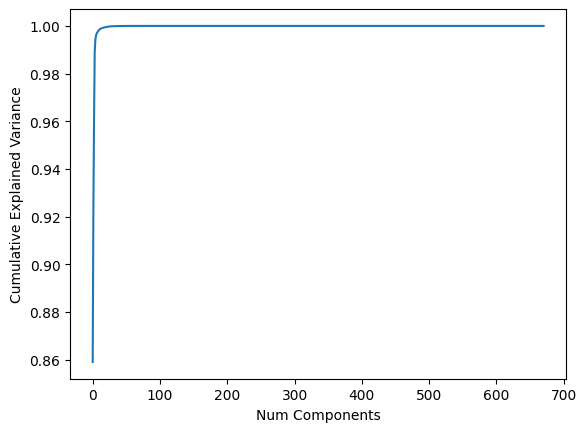

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.plot(np.cumsum(pc3.explained_variance_ratio_))
plt.xlabel('Num Components')
plt.ylabel('Cumulative Explained Variance');

In [34]:
#Data with only closing prices
from sklearn.preprocessing import MinMaxScaler
scl = MinMaxScaler()
scale = MinMaxScaler()
array_train = scl.fit_transform(array_train)
array_test  = scale.fit_transform(array_test) #[0,1]

#Full features dataset; reducing dimensionality here
from sklearn.decomposition import PCA
pcTrain_scl = MinMaxScaler()
pcTest_scl  = MinMaxScaler()
pcaTrain = PCA(n_components = 61)
pcaTest = PCA(n_components = 61)

PCA_train = pcTrain_scl.fit_transform(PCA_train)
PCA_train = pcaTrain.fit_transform(PCA_train)

PCA_test = pcTest_scl.fit_transform(PCA_test)
PCA_test = pcaTest.fit_transform(PCA_test)

In [35]:
print(array_train.shape)
print(PCA_train.shape)

(3804, 61)
(3804, 61)


In [36]:
#Get the data and splits in input X and output Y, by spliting in lookback number of past days as input X
#and horizon number of coming days as Y.
def processData(data, lookback, horizon,num_companies,jump=1):
    X,Y = [],[]
    for i in range(0,len(data) -lookback - horizon +1, jump):
        X.append(data[i:(i+lookback)])
        Y.append(data[(i+lookback):(i+lookback+horizon)])
    return np.array(X),np.array(Y)

In [37]:
num_companies = df_close.shape[1]
lookback = 252 #How many days of the past can the model see
horizon = 22 #How many days into the future are we trying to predict

In [38]:
# Formation of lookback dataframes and forward dataframes for training, and testing dataset
# to calculate accuracy

#Testing Data
X_test, void = processData(PCA_test,lookback,horizon,num_companies,horizon)
void, y_test = processData(array_test,lookback,horizon,num_companies,horizon)
y_test = np.array([list(a.ravel()) for a in y_test])

#Training/Validation Data
X_PCA, void = processData(PCA_train,lookback,horizon,num_companies)
void, y = processData(array_train,lookback,horizon,num_companies)
y = np.array([list(x.ravel()) for x in y])

X_train, X_validate, y_train, y_validate = train_test_split(X_PCA, y, test_size=0.20, random_state=1)

In [39]:
1342/22
#Length y_train/test/validate / forward window == # of features

61.0

In [40]:
print(X_train.shape)
print(X_validate.shape)
print(X_test.shape)
print(y_train.shape)
print(y_validate.shape)
print(y_test.shape)
#(Sample,Timestep,Features)

(2824, 252, 61)
(707, 252, 61)
(31, 252, 61)
(2824, 1342)
(707, 1342)
(31, 1342)


In [41]:
from keras.models import Sequential, load_model
import tensorflow as tf
from keras.layers import LSTM,Dense,Activation,Attention,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import Regularizer
from keras import optimizers

#Model Architecture - Two LSTM layers with x neurons & y epochs
num_neurons_L1 = 800
num_neurons_L2 = 600
num_neurons_dense1 = 200
EPOCHS = 100

#Model
model = Sequential()

model.add(LSTM(num_neurons_L1,input_shape=(lookback,num_companies), return_sequences=True))
model.add(LSTM(num_neurons_L2,input_shape=(num_neurons_L1,1)))
model.add(Dense(horizon * num_companies, activation = 'relu'))
model.add(Dense(horizon * num_companies, activation = 'sigmoid'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics = ['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
history = model.fit(X_train,y_train,epochs=EPOCHS,
                    validation_data=(X_validate,y_validate),
                    shuffle=False,batch_size=256, verbose=2)

Epoch 1/100
12/12 - 16s - 1s/step - accuracy: 0.0096 - loss: 0.0466 - val_accuracy: 0.0071 - val_loss: 0.0240
Epoch 2/100
12/12 - 19s - 2s/step - accuracy: 0.0106 - loss: 0.0227 - val_accuracy: 0.0000e+00 - val_loss: 0.0225
Epoch 3/100
12/12 - 20s - 2s/step - accuracy: 0.0081 - loss: 0.0208 - val_accuracy: 0.0000e+00 - val_loss: 0.0185
Epoch 4/100
12/12 - 20s - 2s/step - accuracy: 0.0096 - loss: 0.0193 - val_accuracy: 0.0028 - val_loss: 0.0176
Epoch 5/100
12/12 - 21s - 2s/step - accuracy: 0.0050 - loss: 0.0178 - val_accuracy: 0.0240 - val_loss: 0.0142
Epoch 6/100
12/12 - 20s - 2s/step - accuracy: 0.0127 - loss: 0.0124 - val_accuracy: 0.0113 - val_loss: 0.0156
Epoch 7/100
12/12 - 20s - 2s/step - accuracy: 0.0124 - loss: 0.0120 - val_accuracy: 0.0297 - val_loss: 0.0103
Epoch 8/100
12/12 - 21s - 2s/step - accuracy: 0.0237 - loss: 0.0099 - val_accuracy: 0.0240 - val_loss: 0.0093
Epoch 9/100
12/12 - 21s - 2s/step - accuracy: 0.0184 - loss: 0.0106 - val_accuracy: 0.0113 - val_loss: 0.0111
Ep

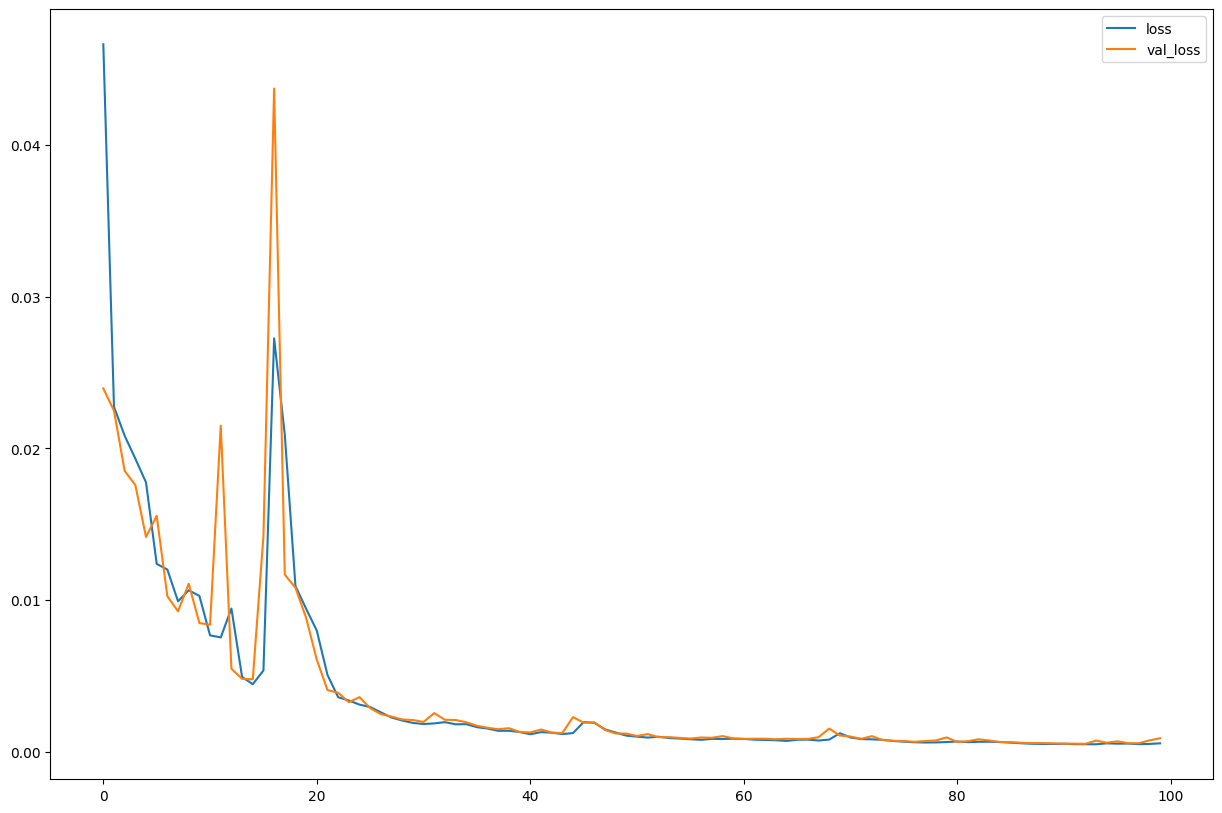

In [43]:
plt.figure(figsize = (15,10))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='best')
plt.show()

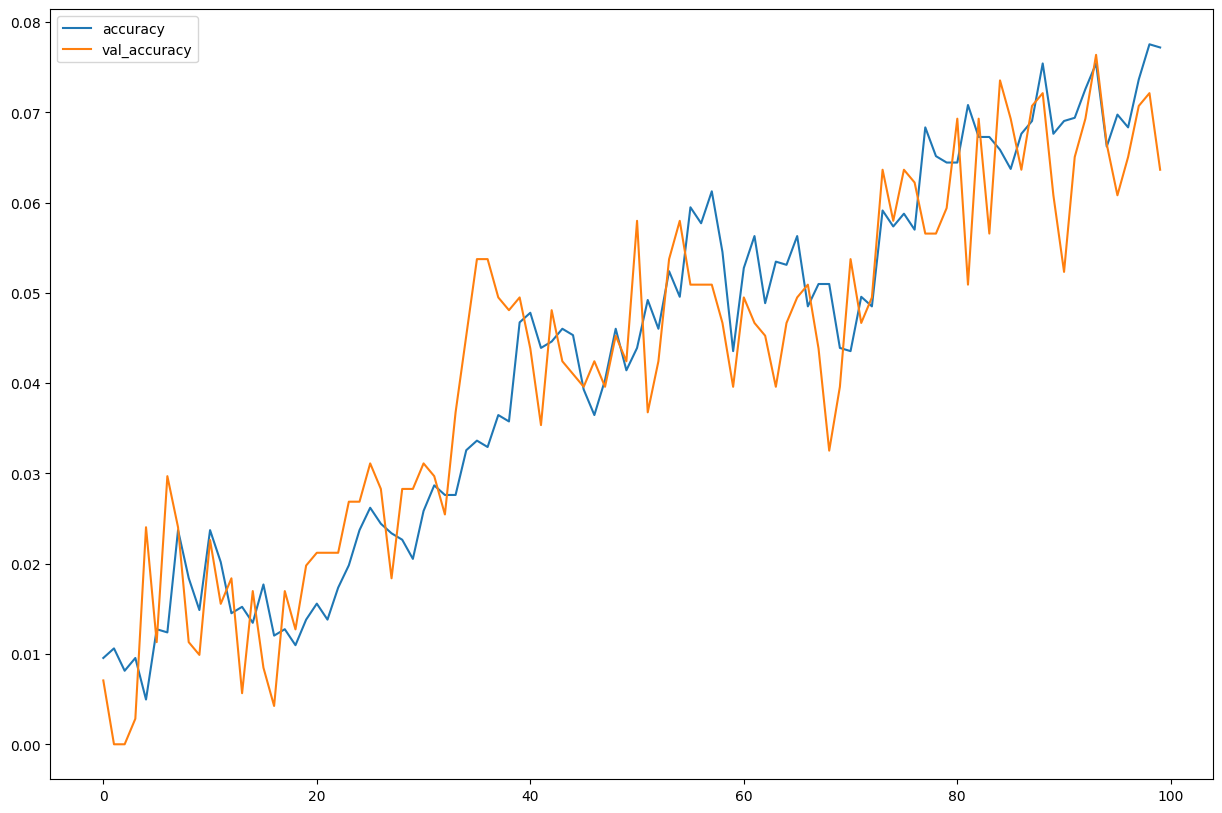

In [44]:
plt.figure(figsize = (15,10))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend(loc='best')
plt.show()

In [45]:
X_test, void = processData(PCA_test,lookback,horizon,num_companies,horizon)
void, y_test = processData(array_test,lookback,horizon,num_companies,horizon)
y_test = np.array([list(a.ravel()) for a in y_test])


Xt = model.predict(X_test)
Xt.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


(31, 1342)

In [46]:
#Aux function 1
def do_inverse_transform(output_result,num_companies):
    #transform to input shape
    original_matrix_format = []
    for result in output_result:
        #do inverse transform
        original_matrix_format.append(scl.inverse_transform([result[x:x+num_companies] for x in range(0, len(result), num_companies)]))
    original_matrix_format = np.array(original_matrix_format)

    #restore to original shape
    for i in range(len(original_matrix_format)):
        output_result[i] = original_matrix_format[i].ravel()

    return output_result

In [47]:
#Aux function 2
def prediction_by_step_by_company(raw_model_output, num_companies):
    matrix_prediction = []
    for i in range(0,num_companies):
        matrix_prediction.append([[lista[j] for j in range(i,len(lista),num_companies)] for lista in raw_model_output])
    return np.array(matrix_prediction)

In [48]:
#Aux function 3
def target_by_company(raw_model_output, num_companies):
    matrix_target = [[] for x in range(num_companies)]

    for output in raw_model_output:
        for i in range (num_companies):
            for j in range(0,len(output),num_companies):
                matrix_target[i].append(output[i+j])
    return np.array(matrix_target)

In [49]:
Xt = do_inverse_transform(Xt, num_companies)
predictions = prediction_by_step_by_company(Xt, num_companies)
predictions.shape

(61, 31, 22)

In [50]:
Yt = do_inverse_transform(y_test, num_companies)

actuals = target_by_company(Yt, num_companies)
actuals.shape

(61, 682)

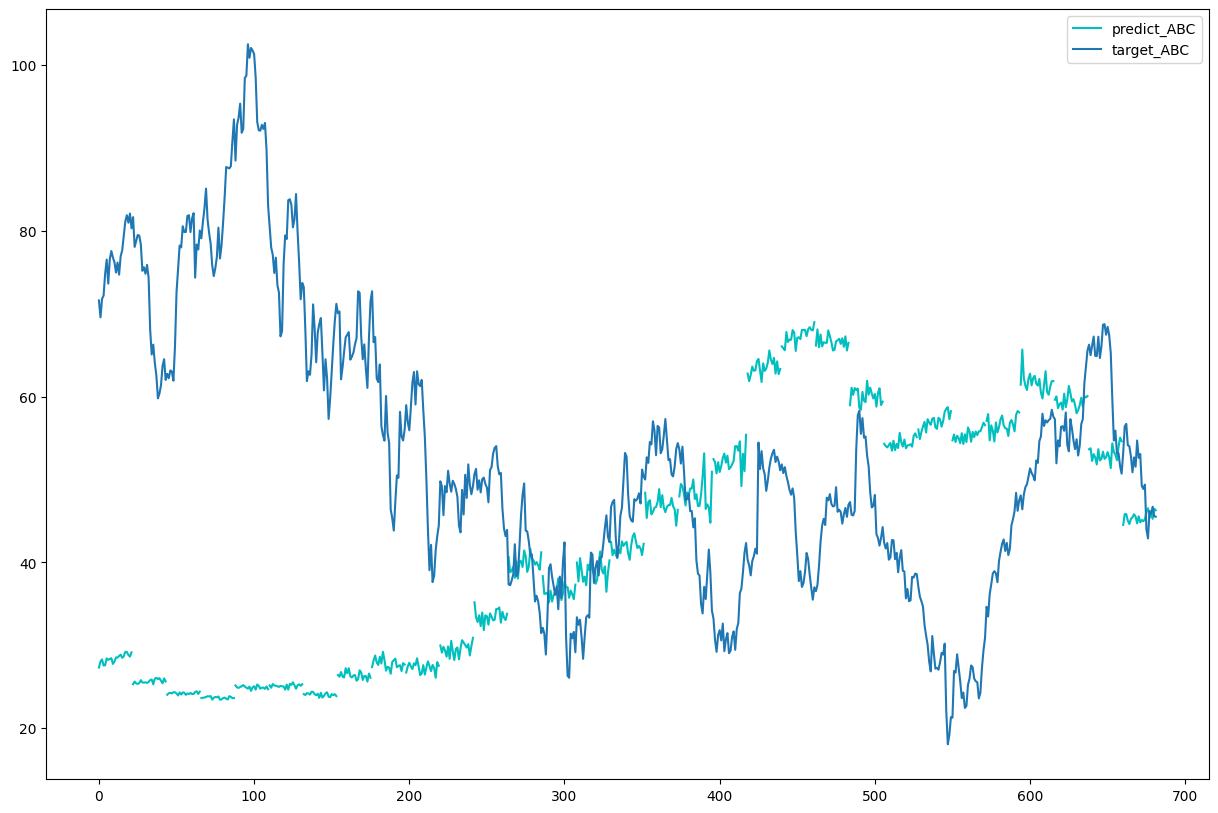

In [51]:
plt.figure(figsize = (15,10))

companies_to_show = [2]
colors = ['r','g','c','m','y','k','w','b']
companies_names = ['A', 'AAPL', 'ABC', 'ABMD']

for id_company in companies_to_show:
    for i in range(0,len(predictions[id_company])):
        plt.plot([x + i*horizon for x in range(len(predictions[id_company][i]))], predictions[id_company][i], color=colors[id_company])
    plt.plot(0,predictions[id_company][0][0] ,color=colors[id_company], label='predict_{}'.format(companies_names[id_company])) #only to place the label



for id_company in companies_to_show:
    plt.plot(actuals[id_company], label='target_{}'.format(companies_names[id_company]))

plt.legend(loc='best')
plt.show()

In [52]:
full_PCA = np.concatenate((PCA_train,PCA_test),axis = 0)

In [53]:
X_all,void = processData(full_PCA,lookback,horizon,num_companies,horizon)
void,y_all = processData(scl.fit_transform(df_close),lookback,horizon,num_companies,horizon)
y_all = np.array([list(a.ravel()) for a in y_all])

In [54]:
Xt = model.predict(X_all)
Xt.shape

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


(204, 1342)

In [55]:
Xt = do_inverse_transform(Xt, num_companies)

predictions = prediction_by_step_by_company(Xt, num_companies)
predictions.shape

(61, 204, 22)

In [56]:
Yt = do_inverse_transform(y_all, num_companies)

actuals = target_by_company(Yt, num_companies)
actuals.shape

(61, 4774)

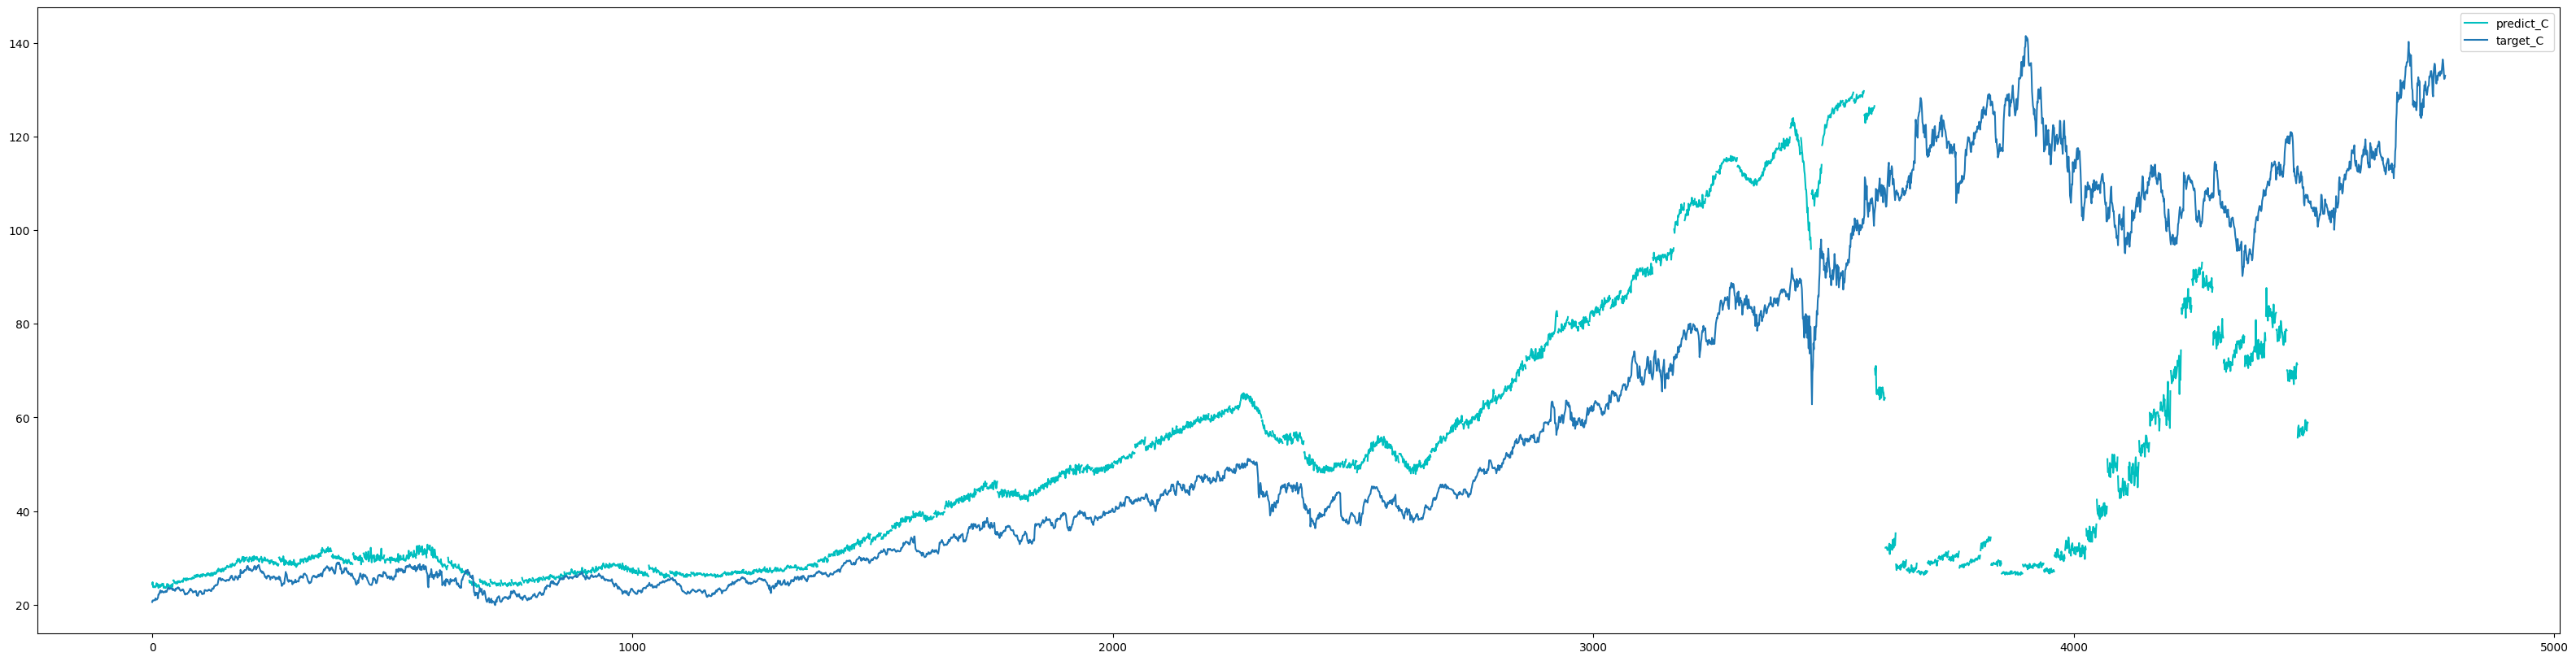

In [57]:
plt.figure(figsize = (40,10))

companies_to_show = [2] #Type a number between 0:4 to see 4 different companies
colors = ['r','g','c','m','y','k','w','b']
companies_names = ['A', 'B', 'C', 'D']


for id_company in companies_to_show:
    for i in range(0,len(predictions[id_company])):
        plt.plot([x + i*horizon for x in range(len(predictions[id_company][i]))], predictions[id_company][i], color=colors[id_company])
    plt.plot(0,predictions[id_company][0][0] ,color=colors[id_company], label='predict_{}'.format(companies_names[id_company])) #only to place the label



for id_company in companies_to_show:
    plt.plot(actuals[id_company], label='target_{}'.format(companies_names[id_company]))

plt.legend(loc='best')
plt.show()

##QQ-plot

In [58]:
predicted_prices = np.zeros((predictions.shape[1]*predictions.shape[2],predictions.shape[0]))
# actual_prices = []

for i in range(predictions.shape[0]):
  counter = 0
  for j in range(predictions.shape[1]):
    for z in range(predictions.shape[2]):
      predicted_prices[counter, i] = predictions[i,j,z]
      counter+=1

print(counter)

4488


In [59]:
actuals_prices = actuals[:,:4488].T

In [60]:
print(predicted_prices.shape)
print(actuals_prices.shape)
print(dates.shape)
#(lookback+1, )

(4488, 61)
(4488, 61)
(5027,)


In [61]:
(5027-lookback+1)-4488

288

In [62]:
# Need to remove certain days because we predict into the future. But, we aren't able to test these predicted days
# against actual days in our porfolio optimization

actual_prices = pd.DataFrame(data = actuals_prices, columns = stocks,index = dates[lookback+1:5028-287])
predicted_prices = pd.DataFrame(data = predicted_prices,columns=stocks, index = dates[lookback+1:5028-287])

In [63]:
actual_prices

Ticker,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2006-06-30,67.851173,7.766667,20.583420,28.100000,30.400000,29.910000,24.809999,18.530001,23.174999,22.539343,...,55.209999,65.470001,46.970001,136.990005,83.000000,29.990000,14.080106,89.059998,16.940001,25.700001
2006-07-03,67.533447,7.726667,20.924078,28.320000,30.360001,28.900000,24.420000,18.450001,23.174999,22.575108,...,54.840000,64.940002,46.320000,139.169998,81.910004,29.860001,14.326585,90.400002,16.840000,25.860001
2006-07-05,67.826088,7.780000,20.909683,28.490000,30.639999,29.469999,24.600000,18.600000,23.405001,22.789700,...,54.630001,65.550003,47.029999,140.630005,81.300003,30.469999,14.128521,91.559998,16.700001,25.740000
2006-07-06,67.349495,7.586667,20.924078,28.440001,29.860001,29.500000,23.900000,18.860001,23.094999,22.410587,...,53.490002,66.300003,46.279999,139.020004,80.169998,29.510000,14.064701,91.260002,16.190001,25.219999
2006-07-07,68.051842,7.568333,21.005644,28.240000,29.590000,29.959999,23.830000,18.990000,23.055000,22.632332,...,53.040001,66.160004,47.040001,140.479996,80.809998,29.270000,14.196743,91.750000,15.750000,25.389999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-24,93.000000,87.919998,107.589996,316.829987,472.899994,78.000000,152.270004,17.129999,83.750000,139.199997,...,75.040001,285.279999,193.179993,766.619995,169.179993,3533.989990,33.340000,62.930000,68.989998,48.990002
2024-04-25,92.019997,87.000000,106.889999,313.540008,477.119995,76.529999,151.740005,17.370001,84.279999,137.490005,...,74.430000,278.209992,201.990005,762.799988,164.330002,3517.520020,33.650002,62.939999,72.910004,48.860001
2024-04-26,91.410004,82.820000,106.860001,309.000000,473.440002,74.709999,153.759995,17.129999,83.730003,136.369995,...,75.239998,275.600006,202.460007,757.650024,166.809998,3502.479980,32.820000,61.950001,73.260002,44.700001


In [64]:
predicted_prices

Ticker,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2006-06-30,60.207165,6.172631,24.379532,36.805256,37.696407,31.749001,49.322235,23.387266,40.750202,32.223454,...,63.043110,85.693344,42.474300,184.482254,78.426239,58.948967,12.763680,93.112953,31.053423,22.967581
2006-07-03,60.357819,6.455530,24.822973,34.899784,39.980885,31.746387,49.120026,23.475712,41.148373,32.147545,...,60.365326,86.595604,42.049110,179.085983,79.774887,69.206734,12.281472,92.930962,30.868511,22.362600
2006-07-05,60.150181,6.856275,23.758751,34.753525,42.317047,31.566319,48.085876,23.611683,41.234577,32.383831,...,62.290642,82.327110,43.762207,177.428162,76.156113,73.207748,12.237402,92.922867,31.416859,22.623220
2006-07-06,60.246941,7.095583,23.746744,36.775127,42.574421,31.564236,50.484020,23.713148,40.706760,31.827581,...,63.557636,83.123413,41.588753,178.705444,75.719101,69.965805,12.816126,94.798332,30.594469,22.431639
2006-07-07,59.350414,6.821800,23.997049,36.786686,39.981842,32.047337,48.509060,23.824524,39.686417,31.821394,...,60.349842,81.270958,41.500523,189.913712,75.132851,59.391499,12.536278,92.690613,31.496357,22.634228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-24,162.750885,69.666695,57.487263,205.512955,193.407761,165.715881,28.988758,13.620451,70.343552,98.554062,...,69.027443,324.034119,262.933563,672.995728,171.738983,4556.751465,35.832886,122.877022,56.213112,55.245281
2024-04-25,164.217712,69.892075,57.992462,209.830048,200.088531,165.298248,29.011585,13.507052,71.421791,98.602097,...,68.634178,316.751587,259.181641,670.366638,176.511703,4592.993652,35.748535,122.516838,57.899708,54.798466
2024-04-26,163.408295,69.953125,57.168083,208.559357,196.656097,165.529831,29.671247,13.522565,71.457245,100.796425,...,68.739288,317.412567,255.430573,686.582214,174.629944,4639.989746,36.317825,123.056564,57.248062,55.808033


In [65]:
predicted_prices.to_csv('PCA_Predicted_Prices1.csv')

In [66]:
actual_prices.to_csv('PCA_Actual_Prices1.csv')